# Chapter 6 — Enhancing BFSI scoring workflows: Advanced binning, monitoring, and explainability

This notebook reproduces the printed code of chapter 6 in book order: listings 6.1–6.9 plus the short unnumbered snippets on pp. 129, 137, and 138.

**Before you run it**

- Run it from inside the `chapter06/` folder. It reads the chapter 5 dataset from `../chapter05/train_df_sample.pkl`. That file is stored with Git LFS; if it is a small text pointer, run `git lfs pull` first.
- Listings 6.1–6.8 need `optbinning`. Listing 6.9 needs `evidently==0.4.40`: its `ColumnMapping`, `evidently.report`, and `evidently.metric_preset` imports aren't available at those paths in newer Evidently releases. Evidently 0.4.40 needs `numpy<2.1`. Appendix A has the full pinned environment.
- No trained model from chapter 5 is needed. The chapter rebuilds the pipeline with OptBinning on the same preprocessed features.

Section 6.3 (LIME, SHAP, partial dependence plots, surrogate models) and sections 6.4–6.5 are conceptual and have no code listings.

## Setup: chapter 5 preprocessing (not a printed listing)

Section 6.1 reuses the chapter 5 preprocessing (listings 5.4 and 5.6, and `feature_list` from listing 5.12). It drops columns with more than 80% missing values, label-encodes the categorical features, and mean-imputes a 100-column numeric sample. The `random.seed(2023)` call matches the chapter 5 notebook, so both chapters work with the same features.

This cell also imports `matplotlib.pyplot as plt`, which listing 6.7 uses. In the book, that import comes from chapter 5's listing 5.3.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="overflow encountered")
warnings.filterwarnings("ignore", message="divide by zero encountered")
warnings.filterwarnings("ignore", message="invalid value encountered in")
warnings.filterwarnings(
    "ignore",
    message="The default of observed=False is deprecated"
)
warnings.filterwarnings("ignore", message="overflow encountered in reduce")

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Listing 5.4, reading the chapter 5 file from inside chapter06/
df = pd.read_pickle("../chapter05/train_df_sample.pkl")
print("Data shape:", df.shape)

# Listing 5.6
def drop_null_cols(df, threshold=0.8):
    null_percent = df.isnull().mean()
    drop_cols = list(null_percent[null_percent > threshold].index)
    df = df.drop(drop_cols, axis=1)
    print(f"Dropped {len(drop_cols)} columns (>{threshold*100}% missing).")
    return df

df = drop_null_cols(df, 0.8)
print("After dropping high-missing columns:", df.shape)

cat_features = [
    "B_30", "B_38", "D_114", "D_116", "D_117",
    "D_120", "D_126", "D_63", "D_64", "D_68"
]
cat_features = [
    f"{cf}_last" for cf in cat_features
]

cat_features = [c for c in cat_features if c in df.columns]

for c in cat_features:
    df[c] = df[c].astype(str)

le_encoder = LabelEncoder()
for c in cat_features:
    df[c] = df[c].replace("nan", "NaN")
    df[c] = le_encoder.fit_transform(df[c])

target_col = "target"
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols
                if col not in cat_features and col != target_col]

random.seed(2023)  # same seed as the chapter 5 notebook -> same 100 numeric columns
num_cols_sample = random.sample(
    numeric_cols,
    min(100, len(numeric_cols))
)
imputer = SimpleImputer(strategy='mean')
df[num_cols_sample] = imputer.fit_transform(df[num_cols_sample])

Data shape: (100000, 919)
Dropped 106 columns (>80.0% missing).
After dropping high-missing columns: (100000, 813)


In [2]:
# Listing 5.12: the feature list
feature_list = num_cols_sample + cat_features
if target_col in feature_list:
    feature_list.remove(target_col)

# Section 6.1.1: feature matrix X and target vector y
X = df[feature_list]
y = df[target_col]
print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (100000, 110) | y shape: (100000,)


### Listing 6.1 — Creating the BinningProcess and specifying selection criteria

*(p. 129)*

In [3]:
from optbinning import BinningProcess, Scorecard
from optbinning.scorecard import plot_auc_roc, plot_cap, plot_ks
from sklearn.linear_model import LogisticRegression

print("Starting OptBinning demonstration with the same BFSI dataset...")

selection_criteria = {
    "iv": {
        "min": 0.025,
        "max": 0.7,
        "strategy": "highest",
        "top": 20
    },
    "quality_score": {
        "min": 0.01
    }
}

binning_process = BinningProcess(
    variable_names=feature_list,
    categorical_variables=cat_features,
    selection_criteria=selection_criteria
)

binning_process.fit(X, y)
print("BinningProcess fit completed.")

Starting OptBinning demonstration with the same BFSI dataset...


BinningProcess fit completed.


### Unnumbered snippet — inspecting the fitted binning process

*(p. 129)*

In [4]:
binning_process.information(print_level=2)
selected_variables = binning_process.get_support(names=True)
print("Selected variables after binning:", selected_variables)

optbinning (Version 0.21.0)
Copyright (c) 2019-2025 Guillermo Navas-Palencia, Apache License 2.0

  Begin options
    max_n_prebins                         20   * d
    min_prebin_size                     0.05   * d
    min_n_bins                            no   * d
    max_n_bins                            no   * d
    min_bin_size                          no   * d
    max_bin_size                          no   * d
    max_pvalue                            no   * d
    max_pvalue_policy            consecutive   * d
    selection_criteria                   yes   * U
    fixed_variables                       no   * d
    categorical_variables                yes   * U
    special_codes                         no   * d
    split_digits                          no   * d
    binning_fit_params                    no   * d
    binning_transform_params              no   * d
    verbose                            False   * d
  End options

  Statistics
    Number of records                 1000

### Listing 6.2 — Inspecting a single binned variable

*(p. 130)*

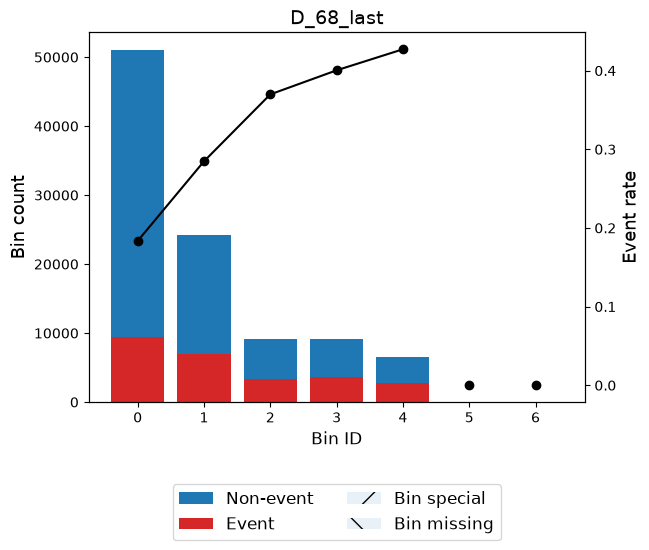

In [5]:
# For example, let's check how "D_68_last" ended up
optb = binning_process.get_binned_variable("D_68_last")
optb.binning_table.build()
optb.binning_table.plot(metric="event_rate")

### Listing 6.3 — Creating and fitting the scorecard

*(p. 132)*

In [6]:
estimator = LogisticRegression(solver="lbfgs", max_iter=1000)
scorecard = Scorecard(
    binning_process=binning_process,
    estimator=estimator,
    scaling_method="min_max",
    scaling_method_params={"min": 300, "max": 850}  # BFSI range
)

scorecard.fit(X, y)
print("Scorecard fitted on X, y.")

Scorecard fitted on X, y.


### Listing 6.4 — Viewing the summary scorecard table

*(p. 132)*

In [7]:
# Summaries in "summary" style
sc = scorecard.table(style="summary")
print(sc)

   Variable           Bin     Points
0   B_8_min  (-inf, 0.00)  41.167598
1   B_8_min  [0.00, 0.00)  40.937473
2   B_8_min  [0.00, 0.00)  40.455755
3   B_8_min  [0.00, 0.01)  38.654012
4   B_8_min  [0.01, 1.00)  20.293323
..      ...           ...        ...
11  P_2_std  [0.06, 0.07)  24.817897
12  P_2_std  [0.07, 0.11)  21.392217
13  P_2_std   [0.11, inf)  16.242831
14  P_2_std       Special  29.252700
15  P_2_std       Missing  29.252700

[227 rows x 3 columns]


### Listing 6.5 — Viewing the detailed scorecard table

*(p. 133)*

In [8]:
sc_detailed = scorecard.table(style="detailed")
print(sc_detailed)

   Variable  Bin id           Bin  Count  Count (%)  Non-event  Event  \
0   B_8_min       0  (-inf, 0.00)  10803    0.10803       9513   1290   
1   B_8_min       1  [0.00, 0.00)   6913    0.06913       6074    839   
2   B_8_min       2  [0.00, 0.00)  32068    0.32068      28042   4026   
3   B_8_min       3  [0.00, 0.01)   5496    0.05496       4714    782   
4   B_8_min       4  [0.01, 1.00)  24653    0.24653      14306  10347   
..      ...     ...           ...    ...        ...        ...    ...   
11  P_2_std      11  [0.06, 0.07)   7875    0.07875       4935   2940   
12  P_2_std      12  [0.07, 0.11)   9908    0.09908       5233   4675   
13  P_2_std      13   [0.11, inf)   9133    0.09133       3456   5677   
14  P_2_std      14       Special      0    0.00000          0      0   
15  P_2_std      15       Missing      0    0.00000          0      0   

    Event rate       WoE        IV        JS  Coefficient     Points  
0     0.119411  0.955528  0.075661  0.009114    -0.4

### Listing 6.6 — Evaluating the scorecard’s rank-ordering

*(p. 134)*

Pred shape: (100000,)


Score range: 317.9053229631041 785.756339856733


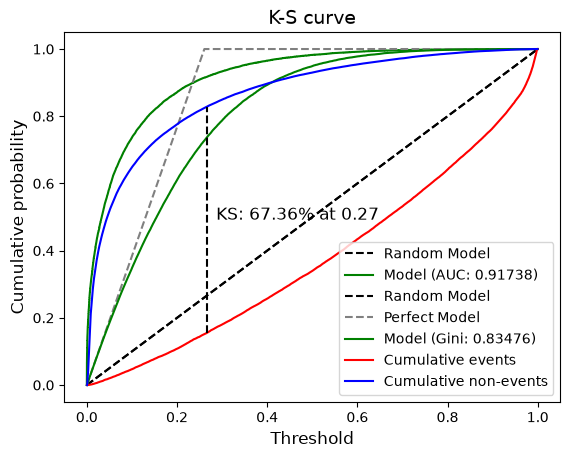

In [9]:
y_pred = scorecard.predict_proba(X)[:, 1]
print("Pred shape:", y_pred.shape)

plot_auc_roc(y, y_pred, title="ROC curve")
plot_cap(y, y_pred, title="CAP curve")
plot_ks(y, y_pred, title="K-S curve")

score = scorecard.score(X)
print("Score range:", score.min(), score.max())

### Listing 6.7 — Plotting the final score distribution (event vs. nonevent)

*(p. 135)*

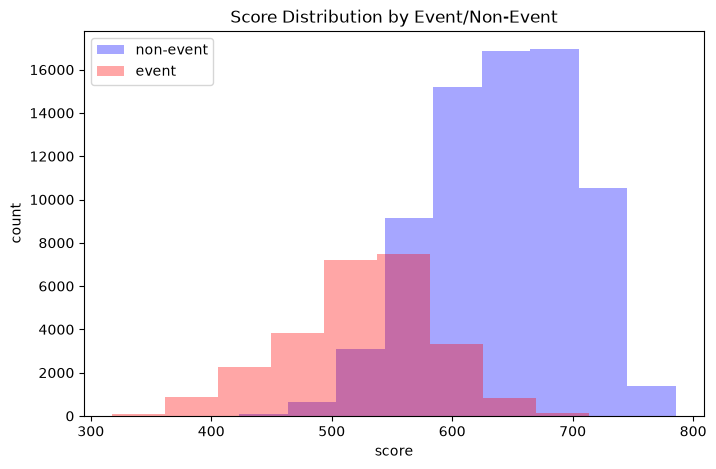

In [10]:
plt.figure(figsize=(8, 5))
mask = (y == 0)
plt.hist(score[mask], label="non-event", color="b", alpha=0.35)
plt.hist(score[~mask], label="event", color="r", alpha=0.35)
plt.xlabel("score")
plt.ylabel("count")
plt.title("Score Distribution by Event/Non-Event")
plt.legend()
plt.show()

### Listing 6.8 — Monitoring distribution stability

*(p. 136)*

In [11]:
from optbinning.scorecard import ScorecardMonitoring
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Re-fit the scorecard on the training subset
scorecard.fit(X_train, y_train)

monitoring = ScorecardMonitoring(
    scorecard=scorecard,
    psi_method="cart",
    psi_n_bins=10,
    verbose=True
)
monitoring.fit(X_test, y_test, X_train, y_train)

2026-10-05 13:57:39,033 | INFO : Monitoring started.


2026-10-05 13:57:39,033 | INFO : Options: check parameters.


2026-10-05 13:57:39,034 | INFO : System stability analysis started.


2026-10-05 13:57:39,294 | INFO : System stability analysis terminated. Time: 0.2601s


2026-10-05 13:57:39,295 | INFO : Variable analysis started.


2026-10-05 13:57:39,379 | INFO : Variable analysis terminated. Time: 0.0846s


2026-10-05 13:57:39,379 | INFO : Monitoring terminated. Time: 0.3469s


,scorecard,"Scorecard(bin..., 'min': 300})"
,psi_n_bins,10
,verbose,True
,psi_method,'cart'
,psi_min_bin_size,0.05
,show_digits,2
,variable_names,"['S_16_min', 'D_128_max', ...]"
,selection_criteria,"{'iv': {'max': 0.7, 'min': 0.025, 'strategy': 'highest', 'top': 20}, 'quality_score': {'min': 0.01}}"
,categorical_variables,"['B_30_last', 'B_38_last', ...]"
,max_n_prebins,20
,min_prebin_size,0.05


### Unnumbered snippet — PSI summary table

*(p. 137)*

In [12]:
psi_table = monitoring.psi_table()
psi_table

,Bin,Count A,Count E,Count A (%),Count E (%),PSI
0,"(-inf, 477.65)",2300,5634,0.076667,0.080486,0.000186
1,"[477.65, 502.33)",1649,3937,0.054967,0.056243,0.000029
2,"[502.33, 534.54)",3038,6854,0.101267,0.097914,0.000113
3,"[534.54, 551.61)",1850,4335,0.061667,0.061929,0.000001
4,"[551.61, 568.92)",2141,4818,0.071367,0.068829,0.000092
5,"[568.92, 591.09)",2669,6370,0.088967,0.091000,0.000046
6,"[591.09, 604.31)",1724,3909,0.057467,0.055843,0.000047
7,"[604.31, 626.24)",2882,6507,0.096067,0.092957,0.000102
8,"[626.24, 661.21)",4179,9782,0.139300,0.139743,0.000001
9,"[661.21, inf)",7568,17854,0.252267,0.255057,0.000031


### Unnumbered snippet — significance tests by bin

*(p. 138)*

In [13]:
tests_result = monitoring.tests_table()
tests_result

,Bin,Count A,Count E,Event rate A,Event rate E,statistic,p-value
0,"(-inf, 477.65)",2300,5634,0.903043,0.911963,1.576749,0.209230
1,"[477.65, 502.33)",1649,3937,0.762887,0.774194,0.841190,0.359057
2,"[502.33, 534.54)",3038,6854,0.619157,0.614240,0.215137,0.642771
3,"[534.54, 551.61)",1850,4335,0.464324,0.433218,5.085762,0.024123
4,"[551.61, 568.92)",2141,4818,0.316207,0.309465,0.314221,0.575102
5,"[568.92, 591.09)",2669,6370,0.183589,0.189011,0.363047,0.546819
6,"[591.09, 604.31)",1724,3909,0.123550,0.113840,1.093364,0.295727
7,"[604.31, 626.24)",2882,6507,0.072866,0.070693,0.142317,0.705988
8,"[626.24, 661.21)",4179,9782,0.027040,0.030055,0.940587,0.332127
9,"[661.21, inf)",7568,17854,0.005550,0.004425,1.419823,0.233432


### Unnumbered snippet — system stability report

*(p. 138)*

`system_stability_report()` prints the report itself and returns `None`, so the `print(system_report)` line as printed adds a trailing `None`.

In [14]:
system_report = monitoring.system_stability_report()
print(system_report)

-----------------------------------
Monitoring: System Stability Report
-----------------------------------

  Population Stability Index (PSI)


    PSI total:      0.0006 (No significant change)

         PSI bin  Count  Count (%)
    [0.00, 0.10)     10        1.0
    [0.10, 0.25)      0        0.0
    [0.25, Inf+)      0        0.0

  Significance tests (H0: actual == expected)

     p-value bin  Count  Count (%)
    [0.00, 0.05)      1        0.1
    [0.05, 0.10)      0        0.0
    [0.10, 0.50)      5        0.5
    [0.50, 1.00)      4        0.4

  Target analysis

               Metric  Actual Actual (%)  Expected Expected (%)
    Number of records   30000          -     70000            -
        Event records    7820   0.260667     18247     0.260671
    Non-event records   22180   0.739333     51753     0.739329

  Performance metrics

                 Metric   Actual  Expected  Diff A - E
     True positive rate 0.654987  0.666082   -0.011095
     True negative rate 0.923

### Before listing 6.9: reset the index (not in the book)

Run exactly as printed, listing 6.9 fails in `combined_report.save_html(...)` with `TypeError: Categorical is not ordered for operation min`. Evidently 0.4.x bins the DataFrame index when it draws its per-column plots, and this dataset's index is the categorical `customer_ID`. The next cell switches `X_train` and `X_test` to a plain integer index.

In [15]:
# Not in the book: give the split data a plain integer index for Evidently 0.4.x.
# Row order is unchanged, so the y_train.values / y_test.values used in
# listing 6.9 still line up.
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

### Listing 6.9 — Creating and saving the Evidently drift report

*(p. 141)*

Needs `evidently==0.4.40` (legacy API). Writes `combined_drift_report.html` into this folder. Expect a different summary from figure 6.9: run after listing 6.8 as printed, the report covers all 110 features plus the target, and this random train/test split shows no dataset drift.

In [16]:
from evidently import ColumnMapping
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset, TargetDriftPreset

df_train = X_train.copy()
df_train["target"] = y_train.values

df_test = X_test.copy()
df_test["target"] = y_test.values

col_map = ColumnMapping(
    target="target",
    numerical_features=X_train.select_dtypes(include="number").columns.tolist(),
    categorical_features=X_train.select_dtypes(exclude="number").columns.tolist()
)

combined_report = Report(
    metrics=[
        DataDriftPreset(),
        TargetDriftPreset()
    ]
)

combined_report.run(
    reference_data=df_train,
    current_data=df_test,
    column_mapping=col_map
)

combined_report.save_html("combined_drift_report.html")
print("Drift report saved to 'combined_drift_report.html'")

Drift report saved to 'combined_drift_report.html'
